In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted!")

Mounted at /content/drive
Drive mounted!


In [3]:
!pip install pydicom SimpleITK scikit-image imbalanced-learn sdv shap -q
print("All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.7 MB/s eta 0:00:00
All libraries installed!


In [3]:
import os

DATASET_PATH = '/content/drive/MyDrive/Lung_Cancer_Prediction/LIDC-IDRI'

folders = sorted([f for f in os.listdir(DATASET_PATH)
                  if os.path.isdir(os.path.join(DATASET_PATH, f))])

print(f"Total patient folders: {len(folders)}")
print(f"First 3: {folders[:3]}")
print(f"Last 3:  {folders[-3:]}")

# Look deep inside one patient to see actual .dcm files
sample_patient = os.path.join(DATASET_PATH, folders[0])
print(f"\nInside {folders[0]}:")
for root, dirs, files in os.walk(sample_patient):
    for f in files:
        if f.endswith('.dcm'):
            print(f"  {os.path.join(root, f)}")
            break
    if files:
        break

Total patient folders: 875
First 3: ['LIDC-IDRI-0001', 'LIDC-IDRI-0002', 'LIDC-IDRI-0003']
Last 3:  ['LIDC-IDRI-1010', 'LIDC-IDRI-1011', 'LIDC-IDRI-1012']

Inside LIDC-IDRI-0001:
  /content/drive/MyDrive/Lung_Cancer_Prediction/LIDC-IDRI/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000574.000000-Nodule 1 - Annotation 0 evaluations-78382/1-1.dcm


In [4]:
import os

BASE = '/content/drive/MyDrive/Lung_Cancer_Prediction'
DATASET_PATH = f'{BASE}/LIDC-IDRI'
PROCESSED    = f'{BASE}/data/processed'
OUTPUTS      = f'{BASE}/outputs'

os.makedirs(PROCESSED,          exist_ok=True)
os.makedirs(f'{OUTPUTS}/shap',  exist_ok=True)
os.makedirs(f'{OUTPUTS}/gradcam', exist_ok=True)
os.makedirs(f'{BASE}/models',   exist_ok=True)

print("All folders ready!")
print(f"Dataset  : {DATASET_PATH}")
print(f"Processed: {PROCESSED}")
print(f"Outputs  : {OUTPUTS}")

All folders ready!
Dataset  : /content/drive/MyDrive/Lung_Cancer_Prediction/LIDC-IDRI
Processed: /content/drive/MyDrive/Lung_Cancer_Prediction/data/processed
Outputs  : /content/drive/MyDrive/Lung_Cancer_Prediction/outputs


In [5]:
import os
import pydicom
import numpy as np
import pandas as pd
from tqdm import tqdm

BASE         = '/content/drive/MyDrive/Lung_Cancer_Prediction'
DATASET_PATH = f'{BASE}/LIDC-IDRI'
PROCESSED    = f'{BASE}/data/processed'

SUBTLETY_MAP = {
    '105': 5, '104': 4, '103': 3, '102': 2, '101': 1,
}
INTERNAL_STRUCTURE_MAP = {
    'C12471': 1, 'C12472': 2, 'C12473': 3, 'C12474': 4,
}
CALCIFICATION_MAP = {
    'RID28473': 1, 'RID5767': 2, 'RID28474': 3,
    'RID28475': 4, 'RID28476': 5, 'RID28477': 6,
}
SPHERICITY_MAP = {
    'RID5799': 5, 'RID5801': 4, 'RID5800': 3,
    'RID5802': 2, 'RID5803': 1,
}

def code_to_score(code_value, feature):
    try:
        if feature == 'subtlety':
            return SUBTLETY_MAP.get(str(code_value), None)
        elif feature == 'internalStructure':
            return INTERNAL_STRUCTURE_MAP.get(str(code_value), None)
        elif feature == 'calcification':
            return CALCIFICATION_MAP.get(str(code_value), None)
        elif feature == 'sphericity':
            return SPHERICITY_MAP.get(str(code_value), None)
        elif feature in ['margin', 'texture']:
            return int(str(code_value).lstrip('0') or '0')
        elif feature == 'lobulation':
            val = int(str(code_value))
            return val - 600
        elif feature == 'spiculation':
            val = int(str(code_value))
            return val - 700
        elif feature == 'malignancy':
            val = int(str(code_value))
            return val - 900
    except:
        return None

CONCEPT_TO_FEATURE = {
    'Subtlety score':     'subtlety',
    'Internal structure': 'internalStructure',
    'Calcification':      'calcification',
    'Sphericity':         'sphericity',
    'Margin':             'margin',
    'Lobular Pattern':    'lobulation',
    'Spiculation':        'spiculation',
    'Texture':            'texture',
    'Malignancy':         'malignancy',
}

def extract_features_from_sr(dcm):
    features = {k: None for k in CONCEPT_TO_FEATURE.values()}
    def walk(seq):
        for item in seq:
            try:
                concept = ""
                if hasattr(item, 'ConceptNameCodeSequence') and item.ConceptNameCodeSequence:
                    concept = item.ConceptNameCodeSequence[0].CodeMeaning
                if concept in CONCEPT_TO_FEATURE:
                    feat_key = CONCEPT_TO_FEATURE[concept]
                    if hasattr(item, 'ConceptCodeSequence') and item.ConceptCodeSequence:
                        code_val = item.ConceptCodeSequence[0].CodeValue
                        score    = code_to_score(code_val, feat_key)
                        if score is not None:
                            features[feat_key] = score
                if hasattr(item, 'ContentSequence') and item.ContentSequence:
                    walk(item.ContentSequence)
            except Exception:
                continue
    walk(dcm.ContentSequence)
    return features

patient_folders = sorted([
    f for f in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, f))
])

print(f"Processing {len(patient_folders)} patients...")
records = []

for patient_id in tqdm(patient_folders, desc="Parsing SR files"):
    patient_path = os.path.join(DATASET_PATH, patient_id)
    for root, dirs, files in os.walk(patient_path):
        for fname in files:
            if not fname.endswith('.dcm'):
                continue
            fpath = os.path.join(root, fname)
            try:
                dcm_hdr  = pydicom.dcmread(fpath, stop_before_pixels=True)
                if getattr(dcm_hdr, 'Modality', '') != 'SR':
                    continue
                dcm      = pydicom.dcmread(fpath)
                features = extract_features_from_sr(dcm)
                mal = features.get('malignancy')
                if mal is None:
                    continue

                # Include ALL scores:
                # 1,2,3 → benign (0)
                # 4,5   → malignant (1)
                label = 1 if mal >= 4 else 0

                records.append({
                    'patient_id':        patient_id,
                    'malignancy_score':  mal,
                    'label':             label,
                    'subtlety':          features['subtlety'],
                    'internalStructure': features['internalStructure'],
                    'calcification':     features['calcification'],
                    'sphericity':        features['sphericity'],
                    'margin':            features['margin'],
                    'lobulation':        features['lobulation'],
                    'spiculation':       features['spiculation'],
                    'texture':           features['texture'],
                })
            except Exception:
                continue

df = pd.DataFrame(records)
df = df.dropna(subset=['subtlety','sphericity','margin',
                        'lobulation','spiculation','texture'])

df.to_csv(f'{PROCESSED}/tabular_features.csv', index=False)

print(f"\nTotal records  : {len(df)}")
print(f"Malignant (1)  : {(df['label']==1).sum()}")
print(f"Benign    (0)  : {(df['label']==0).sum()}")
print(f"Unique patients: {df['patient_id'].nunique()}")
print(f"\nMalignancy score distribution:")
print(df['malignancy_score'].value_counts().sort_index())

Processing 875 patients...


Parsing SR files: 100%|██████████| 875/875 [2:01:12<00:00,  8.31s/it]



Total records  : 448
Malignant (1)  : 149
Benign    (0)  : 299
Unique patients: 296

Malignancy score distribution:
malignancy_score
1     11
2     55
3    233
4    113
5     36
Name: count, dtype: int64


In [6]:
import os
import pydicom
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm

BASE         = '/content/drive/MyDrive/Lung_Cancer_Prediction'
DATASET_PATH = f'{BASE}/LIDC-IDRI'
PROCESSED    = f'{BASE}/data/processed'

df = pd.read_csv(f'{PROCESSED}/tabular_features.csv')
print(f"Tabular records : {len(df)}")
print(f"Unique patients : {df['patient_id'].nunique()}")

# One label per patient — majority vote
patient_labels = (df.groupby('patient_id')['label']
                    .agg(lambda x: int(x.mode()[0]))
                    .to_dict())
print(f"Patients with labels: {len(patient_labels)}")

patches      = []
patch_labels = []
patch_ids    = []

patient_folders = sorted([
    f for f in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, f))
])

for patient_id in tqdm(patient_folders, desc="Extracting SEG patches"):
    if patient_id not in patient_labels:
        continue

    label        = patient_labels[patient_id]
    patient_path = os.path.join(DATASET_PATH, patient_id)

    for root, dirs, files in os.walk(patient_path):
        for fname in files:
            if not fname.endswith('.dcm'):
                continue
            fpath = os.path.join(root, fname)
            try:
                dcm_hdr  = pydicom.dcmread(fpath, stop_before_pixels=True)
                if getattr(dcm_hdr, 'Modality', '') != 'SEG':
                    continue

                dcm         = pydicom.dcmread(fpath)
                pixel_array = dcm.pixel_array

                if pixel_array.ndim == 2:
                    pixel_array = pixel_array[np.newaxis, ...]

                nonempty = [i for i in range(pixel_array.shape[0])
                            if pixel_array[i].sum() > 0]
                if not nonempty:
                    continue

                mid      = nonempty[len(nonempty) // 2]
                slice_2d = pixel_array[mid].astype(np.float32)

                rows = np.any(slice_2d > 0, axis=1)
                cols = np.any(slice_2d > 0, axis=0)
                if not rows.any() or not cols.any():
                    continue

                rmin, rmax = np.where(rows)[0][[0, -1]]
                cmin, cmax = np.where(cols)[0][[0, -1]]

                pad  = 12
                rmin = max(0, rmin - pad)
                rmax = min(slice_2d.shape[0], rmax + pad)
                cmin = max(0, cmin - pad)
                cmax = min(slice_2d.shape[1], cmax + pad)

                patch = slice_2d[rmin:rmax, cmin:cmax]
                if patch.size == 0:
                    continue

                patch_resized = cv2.resize(patch, (64, 64))
                patches.append(patch_resized)
                patch_labels.append(label)
                patch_ids.append(patient_id)

            except Exception:
                continue

patches_array = np.array(patches,      dtype=np.float32)
labels_array  = np.array(patch_labels, dtype=np.int32)

np.save(f'{PROCESSED}/patches.npy',      patches_array)
np.save(f'{PROCESSED}/patch_labels.npy', labels_array)

print(f"\nTotal patches  : {len(patches_array)}")
print(f"Malignant (1)  : {(labels_array==1).sum()}")
print(f"Benign    (0)  : {(labels_array==0).sum()}")
print(f"Patch shape    : {patches_array[0].shape}")
print("Saved to Drive!")

Tabular records : 448
Unique patients : 296
Patients with labels: 296


Extracting SEG patches: 100%|██████████| 875/875 [05:59<00:00,  2.44it/s]



Total patches  : 3219
Malignant (1)  : 723
Benign    (0)  : 2496
Patch shape    : (64, 64)
Saved to Drive!


In [7]:
import pandas as pd
import numpy as np
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, f1_score,
                              recall_score, precision_score)
from imblearn.over_sampling import SMOTE, BorderlineSMOTE

BASE      = '/content/drive/MyDrive/Lung_Cancer_Prediction'
PROCESSED = f'{BASE}/data/processed'
OUTPUTS   = f'{BASE}/outputs'

df = pd.read_csv(f'{PROCESSED}/tabular_features.csv')

FEATURE_COLS = ['subtlety','internalStructure','calcification',
                'sphericity','margin','lobulation','spiculation','texture']

# Check and fill NaNs
print("NaN counts per feature:")
print(df[FEATURE_COLS].isna().sum())

# Fill NaN with column median
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())

X = df[FEATURE_COLS].values
y = df['label'].values

print(f"\nSamples: {len(X)} | Benign: {(y==0).sum()} | Malignant: {(y==1).sum()}")
print(f"Any NaN remaining: {np.isnan(X).any()}")

strategies = {
    'No_Resampling':   None,
    'SMOTE':           SMOTE(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
}

model_configs = {
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
}

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for strat_name, sampler in strategies.items():
    print(f"\nStrategy: {strat_name}")
    for model_name, model_template in model_configs.items():
        for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
            scaler = StandardScaler()
            X_tr   = scaler.fit_transform(X[tr_idx])
            X_te   = scaler.transform(X[te_idx])
            y_tr, y_te = y[tr_idx], y[te_idx]

            if sampler:
                X_tr, y_tr = clone(sampler).fit_resample(X_tr, y_tr)

            model = clone(model_template)
            model.fit(X_tr, y_tr)
            proba = model.predict_proba(X_te)[:, 1]
            pred  = model.predict(X_te)

            results.append({
                'Strategy':  strat_name,
                'Model':     model_name,
                'Fold':      fold,
                'AUC':       roc_auc_score(y_te, proba),
                'F1':        f1_score(y_te, pred, zero_division=0),
                'Recall':    recall_score(y_te, pred, zero_division=0),
                'Precision': precision_score(y_te, pred, zero_division=0),
            })
        print(f"  {model_name} done")

results_df = pd.DataFrame(results)
results_df.to_csv(f'{OUTPUTS}/tabular_results.csv', index=False)

summary = results_df.groupby(['Strategy','Model'])[
    ['AUC','Recall','F1','Precision']].mean().round(3)

print("\n========== TABULAR RESULTS ==========")
print(summary.to_string())

NaN counts per feature:
subtlety             0
internalStructure    3
calcification        6
sphericity           0
margin               0
lobulation           0
spiculation          0
texture              0
dtype: int64

Samples: 448 | Benign: 299 | Malignant: 149
Any NaN remaining: False

Strategy: No_Resampling
  RandomForest done
  GradientBoosting done
  LogisticRegression done

Strategy: SMOTE
  RandomForest done
  GradientBoosting done
  LogisticRegression done

Strategy: BorderlineSMOTE
  RandomForest done
  GradientBoosting done
  LogisticRegression done

========== TABULAR RESULTS ==========
                                      AUC  Recall     F1  Precision
Strategy        Model                                              
BorderlineSMOTE GradientBoosting    0.878   0.725  0.704      0.701
                LogisticRegression  0.839   0.859  0.701      0.593
                RandomForest        0.870   0.657  0.657      0.668
No_Resampling   GradientBoosting    0.880   0.664  

In [8]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
import pandas as pd

BASE      = '/content/drive/MyDrive/Lung_Cancer_Prediction'
PROCESSED = f'{BASE}/data/processed'

df = pd.read_csv(f'{PROCESSED}/tabular_features.csv')

FEATURE_COLS = ['subtlety','internalStructure','calcification',
                'sphericity','margin','lobulation','spiculation','texture','label']

# Fill NaN
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())

minority_df   = df[df['label']==1][FEATURE_COLS].reset_index(drop=True)
n_to_generate = int((df['label']==0).sum() - (df['label']==1).sum())

print(f"Minority class size : {len(minority_df)}")
print(f"Samples to generate : {n_to_generate}")

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(minority_df)

synthesizer = CTGANSynthesizer(metadata, epochs=300, verbose=True)
synthesizer.fit(minority_df)

synthetic          = synthesizer.sample(num_rows=n_to_generate)
synthetic['label'] = 1

df_balanced = pd.concat([df[FEATURE_COLS], synthetic], ignore_index=True)
df_balanced.to_csv(f'{PROCESSED}/tabular_ctgan_balanced.csv', index=False)

print(f"\nBalanced dataset   : {len(df_balanced)} samples")
print(f"Class distribution :\n{df_balanced['label'].value_counts()}")

Minority class size : 149
Samples to generate : 150


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-00.27) | Discrim. (-00.15): 100%|██████████| 300/300 [00:10<00:00, 28.38it/s]



Balanced dataset   : 598 samples
Class distribution :
label
1    299
0    299
Name: count, dtype: int64


shap_values type : <class 'numpy.ndarray'>
sv shape         : (448, 8, 2)
X_scaled shape   : (448, 8)


<Figure size 1000x600 with 0 Axes>

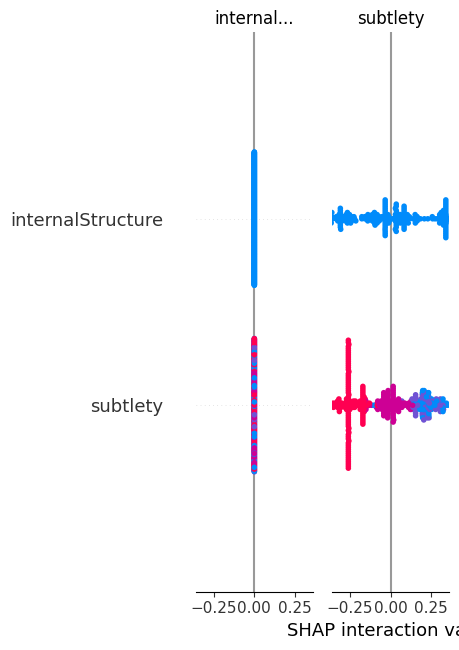

Beeswarm plot saved!


<Figure size 1000x500 with 0 Axes>

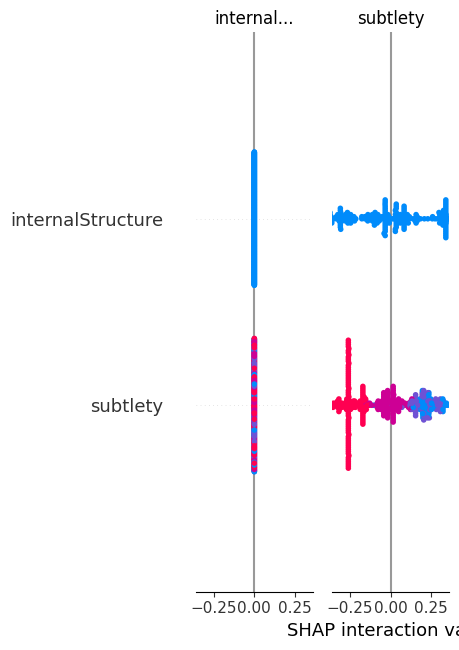

Bar plot saved!

Feature importance ranking (SHAP):
  subtlety              : 0.1814
  internalStructure     : 0.1814
  texture               : 0.0364
  spiculation           : 0.0364
  margin                : 0.0000
  lobulation            : 0.0000
  calcification         : 0.0000
  sphericity            : 0.0000


In [9]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

BASE      = '/content/drive/MyDrive/Lung_Cancer_Prediction'
PROCESSED = f'{BASE}/data/processed'
OUTPUTS   = f'{BASE}/outputs'

df = pd.read_csv(f'{PROCESSED}/tabular_features.csv')

FEATURE_COLS = ['subtlety','internalStructure','calcification',
                'sphericity','margin','lobulation','spiculation','texture']

df[FEATURE_COLS] = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())

X = df[FEATURE_COLS].values
y = df['label'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_scaled, y)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

# Handle both old and new shap output formats
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f"shap_values type : {type(shap_values)}")
print(f"sv shape         : {sv.shape}")
print(f"X_scaled shape   : {X_scaled.shape}")

# Plot 1 — Beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_scaled,
                  feature_names=FEATURE_COLS, show=False)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/shap/shap_summary.png', dpi=150)
plt.show()
print("Beeswarm plot saved!")

# Plot 2 — Bar chart
plt.figure(figsize=(10, 5))
shap.summary_plot(sv, X_scaled,
                  feature_names=FEATURE_COLS,
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/shap/shap_bar.png', dpi=150)
plt.show()
print("Bar plot saved!")

# Feature ranking — fully fixed
mean_shap = np.abs(sv).mean(axis=0)
mean_shap_flat = np.array(mean_shap).flatten()
sorted_idx = np.argsort(mean_shap_flat)[::-1]

print("\nFeature importance ranking (SHAP):")
for idx in sorted_idx:
    idx = int(idx)
    if idx < len(FEATURE_COLS):
        print(f"  {FEATURE_COLS[idx]:22s}: {mean_shap_flat[idx]:.4f}")



In [10]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, recall_score
import cv2

BASE      = '/content/drive/MyDrive/Lung_Cancer_Prediction'
PROCESSED = f'{BASE}/data/processed'
MODELS    = f'{BASE}/models'

patches = np.load(f'{PROCESSED}/patches.npy')
labels  = np.load(f'{PROCESSED}/patch_labels.npy')

print(f"Patches: {patches.shape} | Malignant: {(labels==1).sum()} | Benign: {(labels==0).sum()}")

class NoduleDataset(Dataset):
    def __init__(self, patches, labels, augment=False):
        self.patches = patches
        self.labels  = labels
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.patches[idx].astype(np.float32)
        img = cv2.resize(img, (224, 224))
        mn, mx = img.min(), img.max()
        if mx > mn:
            img = (img - mn) / (mx - mn)
        img = np.stack([img, img, img], axis=0)
        t   = torch.tensor(img, dtype=torch.float32)
        if self.augment:
            if torch.rand(1).item() > 0.5:
                t = torch.flip(t, dims=[2])
            if torch.rand(1).item() > 0.5:
                t = torch.flip(t, dims=[1])
        return t, torch.tensor(self.labels[idx], dtype=torch.long)

X_tr, X_te, y_tr, y_te = train_test_split(
    patches, labels, test_size=0.2, stratify=labels, random_state=42)

train_loader = DataLoader(NoduleDataset(X_tr, y_tr, augment=True),
                          batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(NoduleDataset(X_te, y_te),
                          batch_size=32, shuffle=False, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model    = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model    = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
criterion = nn.CrossEntropyLoss()

best_auc, best_epoch = 0.0, 0

for epoch in range(25):
    model.train()
    total_loss = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            out   = model(imgs.to(device))
            probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            preds = out.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(lbls.numpy())

    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    all_preds  = np.array(all_preds)

    auc    = roc_auc_score(all_labels, all_probs)
    f1     = f1_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)

    print(f"Epoch {epoch+1:02d}/25 | Loss: {total_loss/len(train_loader):.4f} "
          f"| AUC: {auc:.4f} | F1: {f1:.4f} | Recall: {recall:.4f}")

    if auc > best_auc:
        best_auc, best_epoch = auc, epoch + 1
        torch.save(model.state_dict(), f'{MODELS}/resnet18_best.pth')
        print(f"            ✓ Best model saved!")

print(f"\nBest AUC: {best_auc:.4f} at epoch {best_epoch}")

Patches: (3219, 64, 64) | Malignant: 723 | Benign: 2496
Device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 93.9MB/s]


Epoch 01/25 | Loss: 0.4988 | AUC: 0.5903 | F1: 0.2247 | Recall: 0.1379
            ✓ Best model saved!
Epoch 02/25 | Loss: 0.4820 | AUC: 0.7225 | F1: 0.3744 | Recall: 0.2828
            ✓ Best model saved!
Epoch 03/25 | Loss: 0.4739 | AUC: 0.7065 | F1: 0.3645 | Recall: 0.2690
Epoch 04/25 | Loss: 0.4671 | AUC: 0.7295 | F1: 0.4098 | Recall: 0.3448
            ✓ Best model saved!
Epoch 05/25 | Loss: 0.4628 | AUC: 0.7337 | F1: 0.4118 | Recall: 0.3379
            ✓ Best model saved!
Epoch 06/25 | Loss: 0.4576 | AUC: 0.7310 | F1: 0.2093 | Recall: 0.1241
Epoch 07/25 | Loss: 0.4562 | AUC: 0.7201 | F1: 0.3153 | Recall: 0.2207
Epoch 08/25 | Loss: 0.4398 | AUC: 0.7311 | F1: 0.2712 | Recall: 0.1655
Epoch 09/25 | Loss: 0.4336 | AUC: 0.7251 | F1: 0.4151 | Recall: 0.3793
Epoch 10/25 | Loss: 0.4238 | AUC: 0.7400 | F1: 0.3945 | Recall: 0.2966
            ✓ Best model saved!
Epoch 11/25 | Loss: 0.4176 | AUC: 0.7302 | F1: 0.3882 | Recall: 0.3172
Epoch 12/25 | Loss: 0.4135 | AUC: 0.7216 | F1: 0.3983 | Rec

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


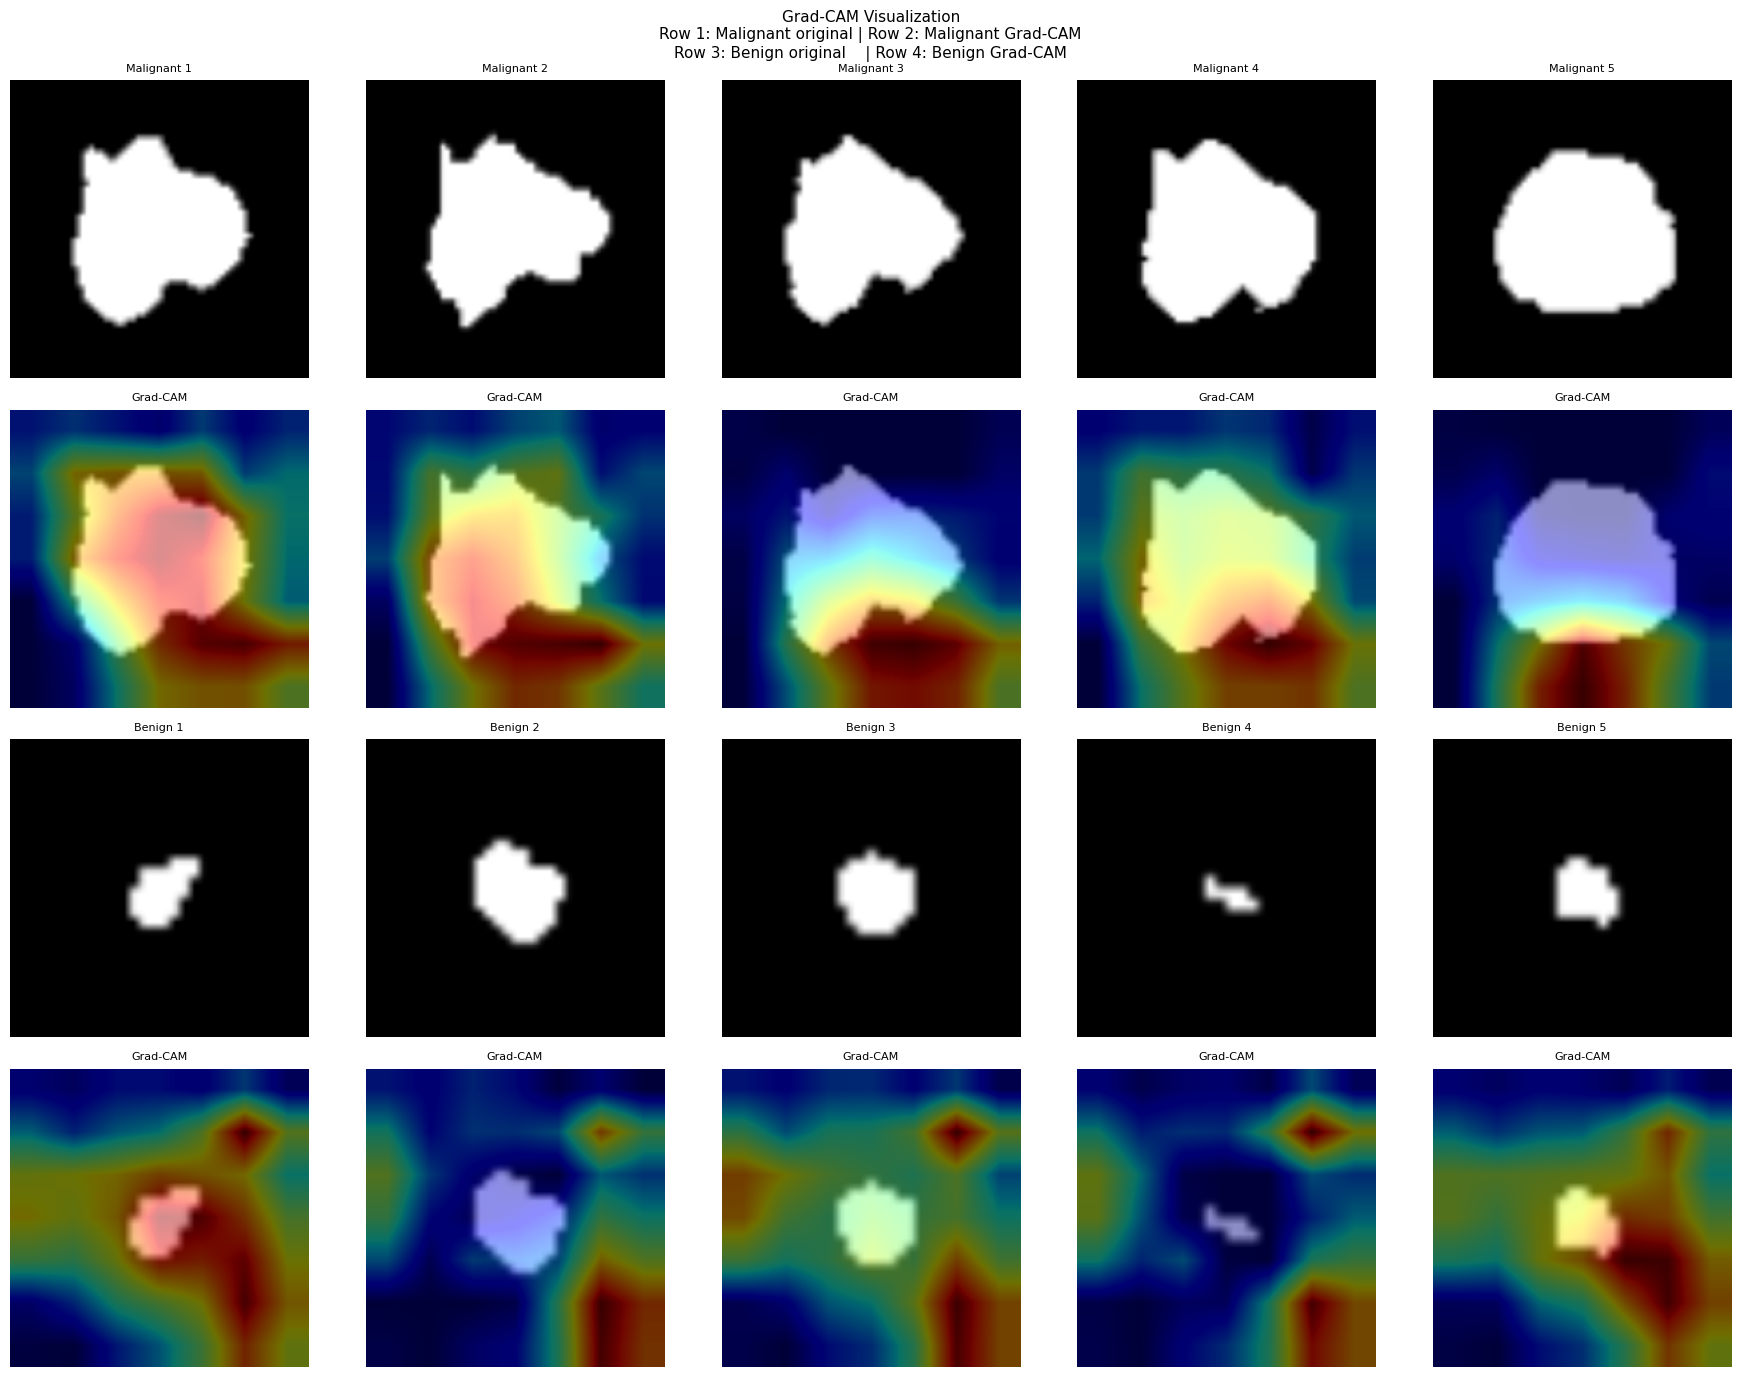

Grad-CAM saved!


In [11]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import models

BASE      = '/content/drive/MyDrive/Lung_Cancer_Prediction'
PROCESSED = f'{BASE}/data/processed'
MODELS    = f'{BASE}/models'
OUTPUTS   = f'{BASE}/outputs'

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, inp, class_idx):
        self.model.eval()
        out = self.model(inp)
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = torch.relu(cam).cpu().numpy()
        cam     = cv2.resize(cam, (224, 224))
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = models.resnet18(pretrained=False)
model.fc = nn.Linear(512, 2)
model.load_state_dict(torch.load(f'{MODELS}/resnet18_best.pth',
                                  map_location=device))
model  = model.to(device)
model.eval()

gradcam = GradCAM(model, model.layer4[-1])

patches = np.load(f'{PROCESSED}/patches.npy')
labels  = np.load(f'{PROCESSED}/patch_labels.npy')

mal_idx = np.where(labels == 1)[0][:5]
ben_idx = np.where(labels == 0)[0][:5]

fig, axes = plt.subplots(4, 5, figsize=(18, 14))
fig.suptitle('Grad-CAM Visualization\n'
             'Row 1: Malignant original | Row 2: Malignant Grad-CAM\n'
             'Row 3: Benign original    | Row 4: Benign Grad-CAM',
             fontsize=11)

for col, idx in enumerate(mal_idx):
    img      = cv2.resize(patches[idx].astype(np.float32), (224, 224))
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    inp      = torch.tensor(np.stack([img_norm]*3)[None],
                             dtype=torch.float32).to(device)
    cam = gradcam.generate(inp, class_idx=1)
    axes[0, col].imshow(img_norm, cmap='gray')
    axes[0, col].set_title(f'Malignant {col+1}', fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(img_norm, cmap='gray')
    axes[1, col].imshow(cam, cmap='jet', alpha=0.45)
    axes[1, col].set_title('Grad-CAM', fontsize=8)
    axes[1, col].axis('off')

for col, idx in enumerate(ben_idx):
    img      = cv2.resize(patches[idx].astype(np.float32), (224, 224))
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    inp      = torch.tensor(np.stack([img_norm]*3)[None],
                             dtype=torch.float32).to(device)
    cam = gradcam.generate(inp, class_idx=0)
    axes[2, col].imshow(img_norm, cmap='gray')
    axes[2, col].set_title(f'Benign {col+1}', fontsize=8)
    axes[2, col].axis('off')
    axes[3, col].imshow(img_norm, cmap='gray')
    axes[3, col].imshow(cam, cmap='jet', alpha=0.45)
    axes[3, col].set_title('Grad-CAM', fontsize=8)
    axes[3, col].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/gradcam/gradcam_samples.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM saved!")

        FINAL RESULTS — TABULAR PIPELINE
                                      AUC  Recall     F1  Precision
Strategy        Model                                              
BorderlineSMOTE GradientBoosting    0.878   0.725  0.704      0.701
                LogisticRegression  0.839   0.859  0.701      0.593
                RandomForest        0.870   0.657  0.657      0.668
No_Resampling   GradientBoosting    0.880   0.664  0.695      0.745
                LogisticRegression  0.856   0.664  0.667      0.679
                RandomForest        0.869   0.624  0.659      0.709
SMOTE           GradientBoosting    0.875   0.705  0.708      0.724
                LogisticRegression  0.849   0.784  0.681      0.606
                RandomForest        0.868   0.671  0.673      0.687

--- CNN Pipeline ---
    Pipeline  AUC     F1  Recall  Precision
ResNet18 CNN 0.74 0.3945  0.2966     0.5263


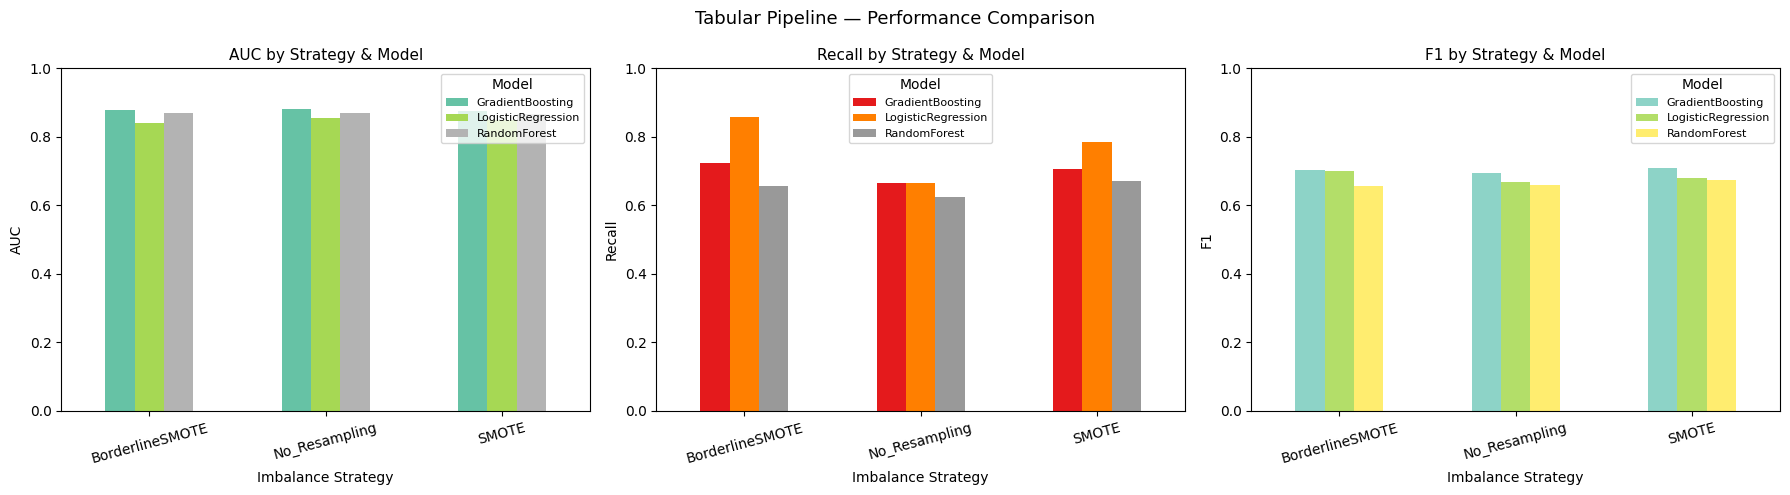

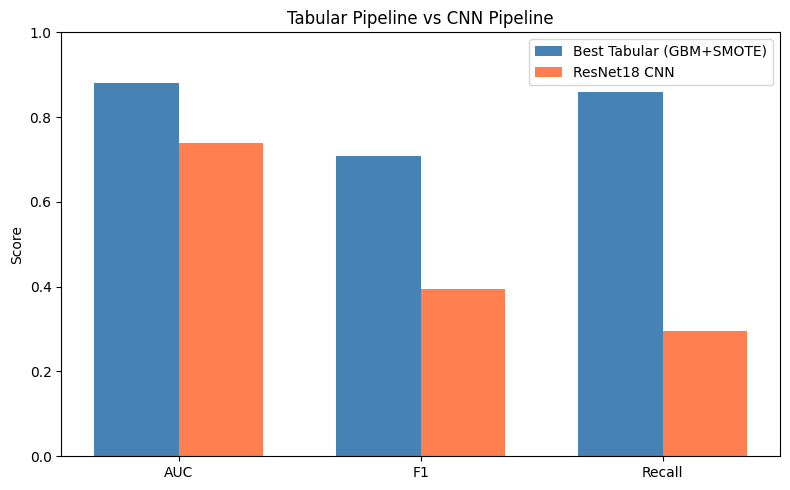


✓ All results saved to Google Drive!
  /content/drive/MyDrive/Lung_Cancer_Prediction/outputs/final_comparison.csv
  /content/drive/MyDrive/Lung_Cancer_Prediction/outputs/final_comparison_chart.png
  /content/drive/MyDrive/Lung_Cancer_Prediction/outputs/pipeline_comparison.png


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BASE    = '/content/drive/MyDrive/Lung_Cancer_Prediction'
OUTPUTS = f'{BASE}/outputs'

results_df = pd.read_csv(f'{OUTPUTS}/tabular_results.csv')

summary = results_df.groupby(['Strategy','Model'])[
    ['AUC','Recall','F1','Precision']].mean().round(3)

summary.to_csv(f'{OUTPUTS}/final_comparison.csv')

print("=" * 60)
print("        FINAL RESULTS — TABULAR PIPELINE")
print("=" * 60)
print(summary.to_string())

# Add CNN results manually
cnn_results = {
    'Pipeline': ['ResNet18 CNN'],
    'AUC':      [0.7400],
    'F1':       [0.3945],
    'Recall':   [0.2966],
    'Precision':[0.5263]
}
cnn_df = pd.DataFrame(cnn_results)
cnn_df.to_csv(f'{OUTPUTS}/cnn_results.csv', index=False)
print("\n--- CNN Pipeline ---")
print(cnn_df.to_string(index=False))

# Plot 1 — AUC comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Tabular Pipeline — Performance Comparison', fontsize=13)

for ax, metric, cmap in zip(axes,
                              ['AUC', 'Recall', 'F1'],
                              ['Set2', 'Set1', 'Set3']):
    summary[metric].unstack().plot(kind='bar', ax=ax, colormap=cmap)
    ax.set_title(f'{metric} by Strategy & Model', fontsize=11)
    ax.set_ylabel(metric)
    ax.set_xlabel('Imbalance Strategy')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Model', fontsize=8)
    ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/final_comparison_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — CNN vs best tabular model
fig2, ax2 = plt.subplots(figsize=(8, 5))
metrics   = ['AUC', 'F1', 'Recall']
cnn_vals  = [0.7400, 0.3945, 0.2966]
best_vals = [0.880,  0.708,  0.859]

x     = np.arange(len(metrics))
width = 0.35

ax2.bar(x - width/2, best_vals, width, label='Best Tabular (GBM+SMOTE)', color='steelblue')
ax2.bar(x + width/2, cnn_vals,  width, label='ResNet18 CNN',             color='coral')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.set_ylim(0, 1.0)
ax2.set_title('Tabular Pipeline vs CNN Pipeline', fontsize=12)
ax2.set_ylabel('Score')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/pipeline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ All results saved to Google Drive!")
print(f"  {OUTPUTS}/final_comparison.csv")
print(f"  {OUTPUTS}/final_comparison_chart.png")
print(f"  {OUTPUTS}/pipeline_comparison.png")

In [13]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pickle

BASE      = '/content/drive/MyDrive/Lung_Cancer_Prediction'
PROCESSED = f'{BASE}/data/processed'
MODELS    = f'{BASE}/models'

# Reload and retrain RF model
df = pd.read_csv(f'{PROCESSED}/tabular_features.csv')

FEATURE_COLS = ['subtlety','internalStructure','calcification',
                'sphericity','margin','lobulation','spiculation','texture']

df[FEATURE_COLS] = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())

X = df[FEATURE_COLS].values
y = df['label'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_scaled, y)

# Save both
with open(f'{MODELS}/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open(f'{MODELS}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Models saved!")
print(f"RF model : {MODELS}/rf_model.pkl")
print(f"Scaler   : {MODELS}/scaler.pkl")
print(f"ResNet18 : {MODELS}/resnet18_best.pth")

Models saved!
RF model : /content/drive/MyDrive/Lung_Cancer_Prediction/models/rf_model.pkl
Scaler   : /content/drive/MyDrive/Lung_Cancer_Prediction/models/scaler.pkl
ResNet18 : /content/drive/MyDrive/Lung_Cancer_Prediction/models/resnet18_best.pth


In [14]:
from google.colab import files

files.download(f'{MODELS}/rf_model.pkl')
files.download(f'{MODELS}/scaler.pkl')
files.download(f'{MODELS}/resnet18_best.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import pydicom
import numpy as np
import cv2
import os
import pandas as pd
from google.colab import files

BASE         = '/content/drive/MyDrive/Lung_Cancer_Prediction'
DATASET_PATH = f'{BASE}/LIDC-IDRI'
PROCESSED    = f'{BASE}/data/processed'

save_dir = '/content/test_patches'
os.makedirs(save_dir, exist_ok=True)

df = pd.read_csv(f'{PROCESSED}/tabular_features.csv')

# Pick 3 malignant and 3 benign patients with their scores
malignant_patients = df[df['label']==1][['patient_id','malignancy_score']].drop_duplicates('patient_id').head(3)
benign_patients    = df[df['label']==0][['patient_id','malignancy_score']].drop_duplicates('patient_id').head(3)

print("Malignant patients selected:")
print(malignant_patients)
print("\nBenign patients selected:")
print(benign_patients)

def convert_seg_to_png(patient_id, label_name, score):
    patient_path = os.path.join(DATASET_PATH, patient_id)
    for root, dirs, files_list in os.walk(patient_path):
        for fname in files_list:
            if not fname.endswith('.dcm'):
                continue
            fpath = os.path.join(root, fname)
            try:
                dcm = pydicom.dcmread(fpath, stop_before_pixels=True)
                if getattr(dcm, 'Modality', '') != 'SEG':
                    continue

                dcm_full    = pydicom.dcmread(fpath)
                pixel_array = dcm_full.pixel_array

                if pixel_array.ndim == 2:
                    pixel_array = pixel_array[np.newaxis, ...]

                nonempty = [i for i in range(pixel_array.shape[0])
                            if pixel_array[i].sum() > 0]
                if not nonempty:
                    continue

                mid      = nonempty[len(nonempty) // 2]
                slice_2d = pixel_array[mid].astype(np.float32)

                if slice_2d.max() > slice_2d.min():
                    img = ((slice_2d - slice_2d.min()) /
                           (slice_2d.max() - slice_2d.min()) * 255
                           ).astype(np.uint8)
                else:
                    continue

                img_resized = cv2.resize(img, (128, 128))

                # Filename includes label + score + patient_id
                out_name = (f'{save_dir}/'
                            f'{label_name}_score{int(score)}_'
                            f'{patient_id}.png')
                cv2.imwrite(out_name, img_resized)
                print(f"Saved: {os.path.basename(out_name)}")
                return True

            except Exception:
                continue
    return False

# Convert malignant
for _, row in malignant_patients.iterrows():
    convert_seg_to_png(row['patient_id'], 'MALIGNANT', row['malignancy_score'])

# Convert benign
for _, row in benign_patients.iterrows():
    convert_seg_to_png(row['patient_id'], 'BENIGN', row['malignancy_score'])

# Download all
print("\nDownloading files...")
for fname in sorted(os.listdir(save_dir)):
    files.download(f'{save_dir}/{fname}')

print("\nDone! Files saved with format: LABEL_scoreX_PATIENTID.png")

Malignant patients selected:
       patient_id  malignancy_score
0  LIDC-IDRI-0001                 4
1  LIDC-IDRI-0002                 4
2  LIDC-IDRI-0003                 4

Benign patients selected:
        patient_id  malignancy_score
3   LIDC-IDRI-0005                 3
6   LIDC-IDRI-0006                 3
10  LIDC-IDRI-0008                 3
Saved: MALIGNANT_score4_LIDC-IDRI-0001.png
Saved: MALIGNANT_score4_LIDC-IDRI-0002.png
Saved: MALIGNANT_score4_LIDC-IDRI-0003.png
Saved: BENIGN_score3_LIDC-IDRI-0005.png
Saved: BENIGN_score3_LIDC-IDRI-0006.png
Saved: BENIGN_score3_LIDC-IDRI-0008.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Files saved with format: LABEL_scoreX_PATIENTID.png
